In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# -----------------------------
# Parameters (invented values)
# -----------------------------
m = 1.5      # kg
L = 1.0      # m
k = 50.0     # N/m
c = 2.0      # Ns/m

# -----------------------------
# External moment M(t)
# Step applied at t = 1 s
# -----------------------------
def M(t):
    return 150.0 if t >= 1.0 else 0.0

# -----------------------------
# System of ODEs
# x1 = theta, x2 = theta_dot
# -----------------------------
def system(t, x):
    theta = x[0]
    theta_dot = x[1]

    theta_ddot = (
        - (3*c/(4*m)) * (np.cos(theta)**2) * theta_dot
        - (3*k/(4*m)) * np.sin(theta) * np.cos(theta)
        + M(t)/(12 * L**2 * m)
    )

    return [theta_dot, theta_ddot]

# -----------------------------
# Initial conditions
# -----------------------------
x0 = [0.0, 0.0]

# Time span
# -----------------------------
t_span = (0, 10)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

# -----------------------------
# Solve using Runge-Kutta (RK45)
# -----------------------------
sol = solve_ivp(system, t_span, x0, t_eval=t_eval, method='RK45')


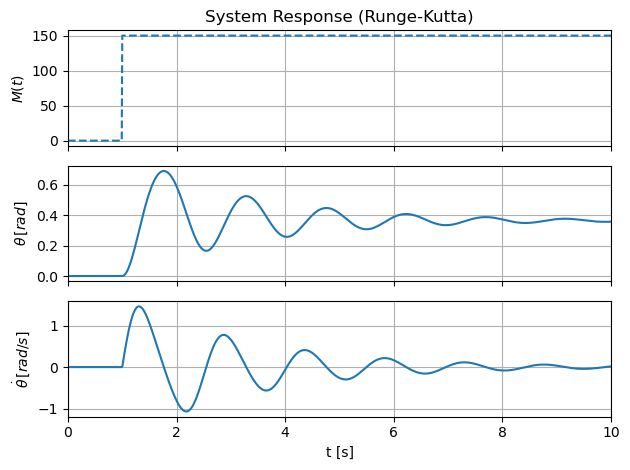

In [2]:
# -----------------------------
# Plot results (3 subplots)
# -----------------------------
fig, axs = plt.subplots(3, 1, sharex=True)

# Input moment
M_vals = [M(t) for t in sol.t]
axs[0].plot(sol.t, M_vals, '--')
axs[0].set_ylabel(r'$M(t)$')
axs[0].grid()
axs[0].set_title('System Response (Runge-Kutta)')

# Theta
axs[1].plot(sol.t, sol.y[0])
axs[1].set_ylabel(r'${\theta}\,[rad]$')
axs[1].grid()

# Theta dot
axs[2].plot(sol.t, sol.y[1])
axs[2].set_ylabel(r'$\dot{\theta}\,[rad/s]$')
axs[2].set_xlabel('t [s]')
axs[2].set_xlim(0, 10) 
axs[2].grid()

plt.tight_layout()
plt.show()